# 축 후보 검증 — 이봉성 · 퍼짐 진단

유형 분류 축 후보들이 **사람을 두 그룹으로 가르는가(이봉성)**, **얼마나 퍼져 있는가(분산)** 를 검증한다.

| 후보 | 컬럼 | 비고 |
|---|---|---|
| J/P 동선 비효율성 | `route_inefficiency_ratio` | 기존 컬럼 |
| 속도 | `speed_z` (신규) | 하루당 방문지 수를 목적지 지역별 z-score |
| 지출액 | `per_person_spend_won`, `total_spend_won` (+log) | 평균/중앙값 컷 비교 |
| 카테고리 엔트로피 | `category_entropy` | 기존 컬럼 |
| 핫플 방문 비율 | `hotplace_ratio` (신규) | 방문빈도 상위 ~25% 장소(2회 이상 방문), 역·터미널 등 교통 거점 제외 |
| 동기 (편의↔목적) | `motive_purpose_ratio` | 기존 컬럼. 방문지 선택이유 중 목적형(지명도·평판·추천·교육성) 비율. 낮을수록 편의형(교통·시설·가성비·우연) |

### 왜 이 지표들인가

유형 분류 축이 되려면 "당신은 A형/B형"이라고 말할 수 있는 **자연 경계**가 분포에 있어야 한다. 분산이 커도 균등하게 퍼진 단봉 분포면 어디서 잘라도 경계 근처에 애매한 사람이 많이 생기고, 이봉 분포면 골짜기에서 잘라 깔끔하게 나뉜다. 그래서 퍼짐과 이봉성을 함께 본다.

| 지표 | 의미 | 판정 기준 |
|---|---|---|
| **min-max 분산** | 1~99% 분위수로 클리핑 후 [0,1] 스케일한 분산. 단위가 다른 컬럼끼리 퍼짐을 비교하기 위함 (z-score는 분산이 전부 1이 되어 비교 불가). 이론상 최대 0.25는 값이 양 끝에 반반 몰릴 때 — 즉 그 자체로 조잡한 이봉성 지표이기도 하다 | 클수록 잘 퍼짐 |
| **Bimodality Coefficient (BC)** | 왜도·첨도 기반 이봉성 계수 | > 0.555면 이봉 의심 (단, 한쪽으로 치우친 단봉도 값이 커지는 한계 있음) |
| **Hartigan dip test** | "분포가 단봉이다"를 귀무가설로 하는 검정 | p < 0.05면 봉우리 2개 이상 |
| **GMM ΔBIC** | 가우시안 혼합모형을 1성분 vs 2성분으로 적합해 BIC 비교. 2성분이 이기면 두 집단 구조 지지, 덤으로 두 그룹의 중심·비율까지 나옴 | ΔBIC > 10이면 2성분 강한 우세 |

지표마다 약점이 달라서(BC는 왜도에 속고, dip은 이산적 값에 속는다) **여러 지표가 교차로 동의하는 컬럼**을 축으로 채택한다.

> 데이터: `features_prototype_all.parquet` — **4권역 Training 전체 10,240건**(수도권·동부권·서부권·제주권 각 2,560건). 권역 간 `TRAVEL_ID` 중복은 없다.
>
> 주의: 이 파일은 현재 `features.py` 코드로 재생성한 것이다. 이전 `features_prototype.parquet`은 `route_inefficiency`가 첫·마지막 좌표를 **포함**하던 시절의 산출물이라 값이 다르다(동부권 2,560건 대조 시 ratio 일치율 12.1%). 아래 §0이 그 차이를 설명한다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import diptest
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

ROOT = Path('..')  # travel_mbti/
REGIONS = ['수도권', '동부권', '서부권', '제주권']   # 4권역 Training 전체
feat = pd.read_parquet(ROOT / 'data/processed/features_prototype_all.parquet')
print(f'{len(REGIONS)}권역 여행 {len(feat):,}건, 컬럼 {feat.shape[1]}개')
print(feat.groupby('region').size().to_string())
feat.shape

4권역 여행 10,240건, 컬럼 40개
region
동부권    2560
서부권    2560
수도권    2560
제주권    2560


(10240, 40)

## 0. 동선의 범위 — 증발·귀가 이동 제외

`route_inefficiency_ratio`는 여행의 **모든** 좌표가 아니라 **첫·마지막을 뺀 중간 방문지**만으로 계산한다([features.py](../src/travel_mbti/features.py)의 `route_inefficiency`).

집에서 여행지까지 가는 이동과 돌아오는 이동은 "동선을 잘 짰는가"와 무관하다. 서울에서 부산으로 간 사실은 계획성이 아니라 목적지 선택이다. 이 두 구간을 넣으면 장거리 이동이 경로 길이를 지배해서, 여행지 안에서의 동선 효율이 묻힌다.

**이 설계가 기계적 1.0을 자동으로 없앤다.** 중간 좌표가 2곳 미만이면 '최적 순서'라는 개념이 성립하지 않으므로 코드가 아예 결측으로 둔다. 별도의 정제 단계가 필요 없다 — 아래 셀이 제외 대상 0건임을 확인한다.

대신 계산 가능한 표본이 줄어든다. **좌표가 4곳은 있어야 중간이 2곳** 나오기 때문이다.

| 좌표 방문지 | 중간 좌표 | 여행 수 | ratio |
|---|---|---|---|
| 0곳 | 0 | 212 | 결측 |
| 1곳 | 0 | 307 | 결측 |
| 2곳 | 0 | 794 | 결측 |
| 3곳 | 1 | 1,239 | 결측 |
| 4곳 이상 | 2+ | 7,688 | 유효 (18건은 경로 길이 0 등으로 결측) |

전체 10,240건 중 **2,570건(25.1%)이 결측**이고, 유효 표본은 7,670건이다. 가장 큰 덩어리는 좌표 3곳(1,239건)이다.

### 기계적 1.0은 사라진 게 아니라 문턱이 옮겨졌다

중간 좌표가 **2곳(m=2)이면 ratio는 계산할 것도 없이 항상 정확히 1.0**이다. 점 두 개 사이의 경로는 하나뿐이라 실제 경로가 곧 최적이기 때문이다. 실제로 m=2인 1,396건은 **전부** ratio=1.0이다.

| 중간 좌표 m | 여행 수 | ratio = 1.0 | 비율 |
|---|---|---|---|
| 2 | 1,396 | 1,396 | **100.0%** |
| 3 | 1,112 | 739 | 66.5% |
| 4 | 922 | 331 | 35.9% |
| 5 | 717 | 137 | 19.1% |
| 9 | 336 | 1 | 0.3% |

m이 커질수록 1.0 비율이 급격히 떨어진다. 즉 **m이 작을 때의 1.0은 계획성이 아니라 경우의 수가 없다는 뜻**이고, m이 클 때의 1.0이라야 진짜 최적 동선이다. §6.2가 `ratio ≈ 1.0`을 이진화 표본에서 빼는 근거가 여기 있다 — 제외되는 2,680건 중 2,135건(79.7%)이 m ≤ 3이다.

> **이전 정의와의 차이**: 첫·마지막을 포함하던 시절에는 좌표 2곳이면 ratio가 자동으로 1.0이 되어, 그 165건을 손으로 결측 처리하는 절이 여기 있었다. 문제 자체는 남아 있고 문턱만 좌표 2곳 → 중간 좌표 2곳으로 옮겨졌다. 같은 동부권 여행을 신·구 정의로 비교하면 경로 길이 일치율이 3.7%에 그친다(예: 118.2km → 97.1km).

In [2]:
mech = (feat['n_coord_visits'] <= 2) & feat['route_inefficiency_ratio'].notna()
print(f'기계적 1.0 제외: {mech.sum()}건 (동선비효율 유효 표본 {feat.route_inefficiency_ratio.notna().sum()}'
      f' → {feat.route_inefficiency_ratio.notna().sum() - mech.sum()})')
feat.loc[mech, 'route_inefficiency_ratio'] = np.nan
spike = (feat['route_inefficiency_ratio'] == 1.0).sum() / feat['route_inefficiency_ratio'].notna().sum()
print(f'정제 후 ratio=1.0(진짜 최적 동선파) 비율: {spike:.1%}')

기계적 1.0 제외: 0건 (동선비효율 유효 표본 7670 → 7670)
정제 후 ratio=1.0(진짜 최적 동선파) 비율: 34.9%


## 1. 속도 — 하루당 방문지 수, 목적지 지역별 z-score

"여행 동안 남들에 비해 얼마나 돌아다녔는지"를 재는 축. 두 가지 보정을 넣는다.

1. **총 방문지 수가 아니라 하루당 방문지 수** — 총 방문지 수는 여행이 길수록 커지는 왜곡이 있어서 `n_tourism_visits / trip_days`로 여행 길이를 보정한다.
2. **목적지 지역별 z-score** — 제주처럼 볼거리가 밀집한 지역과 한적한 지역은 하루 방문지 수의 기본값 자체가 다르다. 같은 지역에 간 사람들 안에서의 상대적 위치(z-score)로 바꿔야 "빡빡한 여행자 vs 느긋한 여행자"라는 사람의 성향이 되고, 지역 특성이 섞이지 않는다.

**4권역 확장으로 이 축의 최대 약점이 해소됐다.** 동부권만 쓸 때는 표본 1~6건뿐인 지역(서울·경기·충북·대전·전북, 총 12건)의 z값이 불안정했다. 지금은 목적지 지역 18곳 모두 **최소 95건**(중앙값 492건, 최대 1,679건)이고 표본 10건 미만인 지역이 없다. `speed_z` 결측도 6건뿐이다.

In [3]:
feat['visits_per_day'] = feat['n_tourism_visits'] / feat['trip_days']
grp = feat.groupby('TRAVEL_STATUS_DESTINATION')['visits_per_day']
feat['speed_z'] = grp.transform(lambda s: (s - s.mean()) / s.std(ddof=0))
grp.size().sort_values(ascending=False)

TRAVEL_STATUS_DESTINATION
경기       1679
제주       1499
강원        961
서울        842
전남        694
경북        672
충남        646
전북        507
부산        494
경남        490
충북        425
대전        405
인천        369
대구        146
도서 지역     118
광주        102
울산         96
세종         95
Name: visits_per_day, dtype: int64

## 2. 핫플 방문 비율 (교통 거점 제외)

"남들 다 가는 유명한 곳을 따라가는 여행자인가, 아무도 안 가본 곳을 찾아가는 여행자인가"를 재는 축. 외부 목록 없이 데이터 안에서 정의한다: 관광 방문지를 방문지명 기준으로 집계해 **많이 방문된 상위 ~25% 장소를 핫플**로 정의하고, 여행별로 전체 방문 중 핫플 방문의 비율을 계산한다.

**교통 거점 제외**: 방문 횟수 상위권에 제주 국제공항·서울역 같은 공항·역이 올라오는데, 이는 인기 관광지가 아니라 단순 경유지다. 두 겹으로 거른다.

1. 방문지 유형코드 9(교통시설)는 전부 제외. 단, 유형코드는 사용자 입력이라 노이즈가 있어 (부산역이 코드 2·4·11·21 등으로도 입력됨) 이것만으로는 부족하다.
2. 이름이 역/터미널/공항/휴게소로 끝나는 곳도 제외 — 단 '강촌레일파크 김유정역', '삼척 해상 케이블카 용화역'처럼 케이블카·레일·모노레일·유람선 키워드가 있는 곳은 교통이 아니라 어트랙션이므로 살린다.

이 규칙으로 방문 기록 90,784건 중 12,905건(**14.2%**)이 제외된다. 남은 기록의 고유 장소는 35,778곳이고, 동률 문제로 정확한 25% 컷이 불가능해 25%에 가장 가까운 **2회 이상 방문**(10,005곳, 28.0%)을 채택했다.

> **이 지표는 축 후보에서 제외했다**(§6·§판정 요약). 장소의 대부분이 1회만 등장해 컷이 사실상 '2회 이상'으로 강제되고, 방문지명이 자유 입력이라 같은 지점이 여러 이름으로 쪼개지기 때문이다. 계산 자체는 비교용으로 남겨둔다.

In [4]:
visits = pd.concat(
    [pd.read_csv(next((ROOT / f'data/raw/{r}/Training').glob('tn_visit_area_info*.csv')))
     for r in REGIONS],
    ignore_index=True)
visits = visits[visits['VISIT_AREA_TYPE_CD'].between(1, 13)].copy()
visits['place'] = visits['VISIT_AREA_NM'].astype(str).str.strip()
# 교통 거점 제외: 유형코드 9 + 이름 규칙(관광 어트랙션은 예외)
is_hub = (visits['VISIT_AREA_TYPE_CD'] == 9) | (
    visits['place'].str.match(r'.*(역|터미널|공항|휴게소)$')
    & ~visits['place'].str.contains('케이블카|레일|모노레일|유람선')
)
print(f'교통 거점으로 제외된 방문 기록: {is_hub.sum()} / {len(visits)} ({is_hub.mean():.1%})')
print('제외 예시:', list(visits.loc[is_hub, "place"].value_counts().head(6).index))
visits = visits[~is_hub].copy()
place_counts = visits.groupby('place')['TRAVEL_ID'].count().sort_values(ascending=False)
shares = {c: (place_counts >= c).mean() for c in range(2, int(place_counts.max()) + 1)}
cut = min(shares, key=lambda c: abs(shares[c] - 0.25))
hot_places = set(place_counts[place_counts >= cut].index)
print(f'고유 장소 {len(place_counts)}개, 컷 {cut}회 이상 → 핫플 {len(hot_places)}개 ({shares[cut]:.1%})')
print('핫플 top10:', list(place_counts.head(10).index))
visits['is_hot'] = visits['place'].isin(hot_places)
hot_ratio = visits.groupby('TRAVEL_ID')['is_hot'].mean().rename('hotplace_ratio')
feat = feat.merge(hot_ratio, on='TRAVEL_ID', how='left')

교통 거점으로 제외된 방문 기록: 12905 / 90784 (14.2%)
제외 예시: ['제주 국제공항', '김포국제공항 국내선', '서울역', '부산역', '대전역', '동대구역']
고유 장소 35778개, 컷 2회 이상 → 핫플 10005개 (28.0%)
핫플 top10: ['제주동문시장', '서귀포 매일 올레시장', '함덕해수욕장', '성심당 본점', '협재해수욕장', '광안리해수욕장', '성산일출봉', '황련단길', '오설록 티 뮤지엄', '전주한옥마을']


## 3. 검증 지표 계산

지출액은 원 단위 그대로면 오른쪽 꼬리(고액 소비자)가 길어 지표가 왜곡될 수 있으므로 log 변환 버전도 함께 검증한다. 결과 표의 컬럼:

- `variance` / `minmax_var`: 원 분산 / 클리핑·정규화 후 분산(컬럼 간 비교용, 최대 0.25)
- `BC`, `dip`, `dip_p`, `dBIC_2c`: 이봉성 지표 3종
- `gmm2_means`, `gmm2_weights`: 2성분 GMM이 찾은 두 그룹의 중심과 비율 → "어디서 갈리는지"의 근거
- `pct_above_mean` / `pct_above_median`: 평균/중앙값 컷으로 잘랐을 때 위쪽 비율 → 컷 기준 선택(평균 vs 중앙값) 판단용

In [5]:
feat['per_person_spend_log'] = np.log1p(feat['per_person_spend_won'])
feat['total_spend_log'] = np.log1p(feat['total_spend_won'])
CANDIDATES = [
    ('route_inefficiency_ratio', 'J/P 동선 비효율성'),
    ('speed_z',                  '속도(하루당 방문지, 지역별 z)'),
    ('per_person_spend_won',     '1인당 지출액(원)'),
    ('per_person_spend_log',     '1인당 지출액(log)'),
    ('total_spend_won',          '총 지출액(원)'),
    ('total_spend_log',          '총 지출액(log)'),
    ('category_entropy',         '카테고리 엔트로피'),
    ('hotplace_ratio',           '핫플 방문 비율'),
    ('motive_purpose_ratio',     '동기(편의형↔목적형)'),
]

def bimodality_coefficient(x):
    n = len(x)
    g = stats.skew(x, bias=False)
    k = stats.kurtosis(x, bias=False)
    return (g**2 + 1) / (k + 3 * (n - 1)**2 / ((n - 2) * (n - 3)))

def minmax_var(x, lo=0.01, hi=0.99):
    a, b = np.quantile(x, [lo, hi])
    y = (np.clip(x, a, b) - a) / (b - a)
    return y.var(ddof=0)

rows = []
for col, label in CANDIDATES:
    x = feat[col].dropna().to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    dip, dip_p = diptest.diptest(x)
    xs = ((x - x.mean()) / x.std(ddof=0)).reshape(-1, 1)
    bics, means, weights = {}, None, None
    for k in (1, 2):
        gm = GaussianMixture(n_components=k, n_init=5, random_state=0).fit(xs)
        bics[k] = gm.bic(xs)
        if k == 2:
            means = (gm.means_.ravel() * x.std(ddof=0) + x.mean()).round(3)
            weights = gm.weights_.round(2)
    rows.append({
        'column': col, 'label': label, 'n': len(x),
        'variance': x.var(ddof=0),
        'minmax_var': round(minmax_var(x), 4),
        'BC': round(bimodality_coefficient(x), 3),
        'dip': round(dip, 4), 'dip_p': round(dip_p, 4),
        'dBIC_2c': round(bics[1] - bics[2], 1),
        'gmm2_means': means, 'gmm2_weights': weights,
        'mean': round(x.mean(), 3), 'median': round(np.median(x), 3),
        'pct_above_mean': round((x > x.mean()).mean(), 3),
        'pct_above_median': round((x > np.median(x)).mean(), 3),
    })

res = pd.DataFrame(rows)
res.to_csv(ROOT / 'outputs/tables/axis_candidate_validation.csv', index=False)
res

,column,label,n,variance,minmax_var,BC,dip,dip_p,dBIC_2c,gmm2_means,gmm2_weights,mean,median,pct_above_mean,pct_above_median
0,route_inefficiency_ratio,J/P 동선 비효율성,7670,1.502450e-01,0.0578,0.561,0.0020,1.0000,29840.9,"[1.0, 1.451]","[0.36, 0.64]",1.290,1.101,0.358,0.500
1,speed_z,"속도(하루당 방문지, 지역별 z)",10234,1.000000e+00,0.0422,0.343,0.0178,0.0000,961.2,"[0.811, -0.399]","[0.33, 0.67]",-0.000,-0.159,0.463,0.495
2,per_person_spend_won,1인당 지출액(원),10237,5.112010e+10,0.0386,0.354,0.0017,1.0000,10027.8,"[419588.218, 94081.114]","[0.25, 0.75]",176937.314,106350.000,0.318,0.500
3,per_person_spend_log,1인당 지출액(log),10237,1.079918e+00,0.0488,0.345,0.0026,0.9727,-26.5,"[10.883, 12.27]","[0.51, 0.49]",11.566,11.575,0.503,0.500
4,total_spend_won,총 지출액(원),10237,2.747999e+11,0.0351,0.370,0.0015,1.0000,10283.1,"[214442.298, 1013817.142]","[0.77, 0.23]",401727.951,231200.000,0.316,0.500
5,total_spend_log,총 지출액(log),10237,1.172472e+00,0.0453,0.340,0.0027,0.9582,-51.0,"[11.648, 13.086]","[0.51, 0.49]",12.346,12.351,0.501,0.500
6,category_entropy,카테고리 엔트로피,10234,1.527408e-01,0.0444,0.390,0.0553,0.0000,479.6,"[0.866, 1.316]","[0.45, 0.55]",1.114,1.099,0.488,0.489
7,hotplace_ratio,핫플 방문 비율,10233,7.216457e-02,0.0722,0.484,0.0558,0.0000,818.6,"[0.417, 0.81]","[0.47, 0.53]",0.626,0.667,0.542,0.450
8,motive_purpose_ratio,동기(편의형↔목적형),10234,6.422868e-02,0.0642,0.433,0.0736,0.0000,415.8,"[0.427, 0.766]","[0.39, 0.61]",0.634,0.667,0.540,0.435


## 4. 분포 확인 — 히스토그램 + 평균/중앙값 컷 위치

숫자 지표만 믿지 말고 눈으로 분포를 확인한다. 빨간 점선이 평균 컷, 주황 실선이 중앙값 컷. 두 선이 많이 벌어져 있을수록 꼬리가 긴 분포라는 뜻이고, 그 경우 평균 컷은 꼬리에 끌려 50:50이 아닌 비대칭 분할이 된다(지출액 raw가 전형적 사례). 표시 범위는 1~99% 분위수로 클리핑.

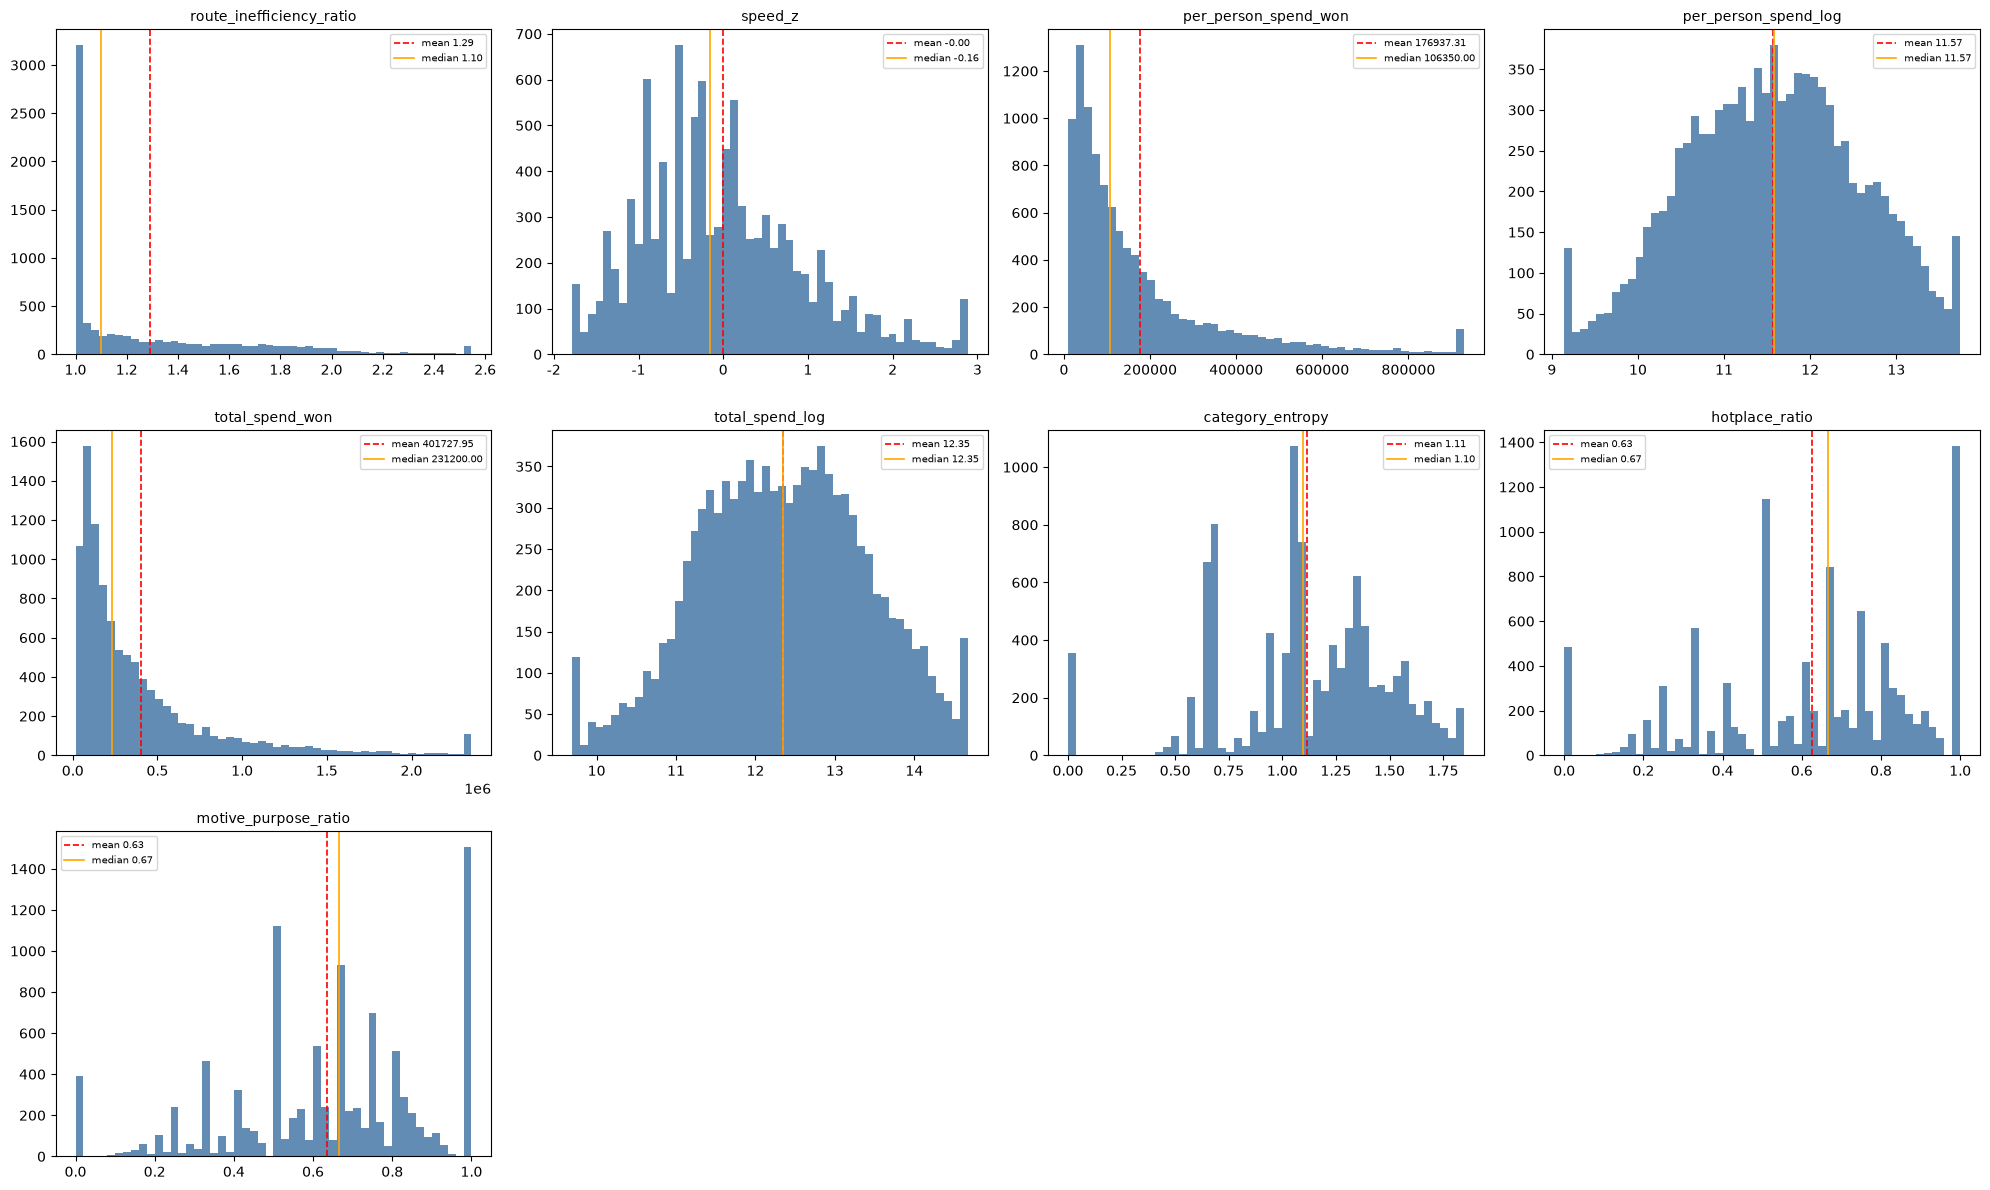

In [6]:
plt.rcParams['axes.unicode_minus'] = False
NCOL = 4
NROW = int(np.ceil(len(CANDIDATES) / NCOL))  # 후보 수에 맞춰 자동 확장
fig, axes = plt.subplots(NROW, NCOL, figsize=(5 * NCOL, 4 * NROW))
for ax, (col, label) in zip(axes.ravel(), CANDIDATES):
    x = feat[col].dropna().to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    a, b = np.quantile(x, [0.01, 0.99])
    ax.hist(np.clip(x, a, b), bins=50, color='#4878a8', alpha=0.85)
    ax.axvline(x.mean(), color='red', ls='--', lw=1.2, label=f'mean {x.mean():.2f}')
    ax.axvline(np.median(x), color='orange', ls='-', lw=1.2, label=f'median {np.median(x):.2f}')
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=7)
for ax in axes.ravel()[len(CANDIDATES):]:  # 남는 칸 숨김
    ax.axis('off')
fig.tight_layout()
fig.savefig(ROOT / 'outputs/figures/axis_candidate_validation.png', dpi=110)
plt.show()

## 5. 신규 컬럼 포함 데이터 저장

In [7]:
feat.to_parquet(ROOT / 'data/processed/features_axis_candidates.parquet', index=False)
print('saved:', ROOT / 'data/processed/features_axis_candidates.parquet')

saved: ../data/processed/features_axis_candidates.parquet


## 6. 축 간 독립성 체크

좋은 좌표축은 서로 직교해야 한다 — 축 A가 축 B를 예측할 수 있다면 두 축은 겹치는 정보를 재고 있고, 유형 조합의 한쪽 사분면이 비게 된다. 반대로 각 축은 타깃(여행자)에 대한 설명력은 가져야 한다. 즉 **"각 축은 저마다 여행자를 설명하되, 서로를 설명하지는 않아야 한다."**

세 겹으로 확인한다.

1. **연속값 상관** — Spearman(순위 기반, 스파이크·꼬리에 강건)과 Pearson. 경험적 기준: |ρ| < 0.3 양호, 0.3~0.5 주의, > 0.5 중복.
2. **이진화 후 phi 상관** — 실제 유형 분류는 이진화한 뒤 이뤄지므로, 이진화 기준 적용 후에도 독립적인지 확인. 이진화 기준은 **세 축 모두 평균 컷**(J/P는 평균 이하가 J, 나머지는 평균 초과가 1). 기준을 하나로 통일해 축마다 다른 컷을 쓴다는 자의성을 없앴다. 다만 J/P의 의미가 바뀐다 — 절대 기준('사실상 최적 동선')이 아니라 **상대 기준**('남들보다 덜 돌아갔다')이 된다.
3. **조합 셀 점유** — 2³ = 8개 유형 조합에 실제로 사람이 다 존재하는지. 빈 셀이 있으면 축이 중복이라는 신호다.

### 이진화 표본에서 `ratio ≈ 1.0`을 제외한다

중간 동선이 이미 최적인 여행 **2,680건**(ratio 유효 7,670건의 34.9%)을 뺀다. 연속적인 우회 정도를 재는 축 위에서 이들은 별개의 덩어리로 남아 평균을 끌어내린다. 이진화 표본은 **7,670 − 2,680 = 4,990건**이다.

제외 기준은 `np.isclose`를 쓴다. 현재 정의에서는 `== 1.0`과 결과가 같지만(둘 다 2,680건, 1.0 미만 0건) — 최적 순서를 달성한 여행은 실제 경로와 최적 경로가 같은 값을 같은 순서로 더하므로 부동소수점 오차가 생기지 않는다 — 계산 방식이 바뀌면 오차가 다시 생길 수 있어 안전한 쪽을 유지한다.

> **이것은 표본 손실이 아니라 필터다.** 제외되는 쪽은 애초에 동선 효율을 논할 수 없는 여행이다. 세 집단의 중앙값을 비교하면 분명하다.
>
> | 집단 | 여행 수 | 관광 방문지 | 여행일수 |
> |---|---|---|---|
> | ratio 계산 불가 | 2,570 | 3곳 | 2일 |
> | ratio ≈ 1.0 | 2,680 | 5곳 | 2일 |
> | **최종 표본** | **4,990** | **10곳** | **3일** |
>
> 걸러지는 것은 1박2일에 3~5곳 다녀온 일정이고, 남는 것은 2박3일에 10곳을 도는 여행이다. 방문지가 두세 곳뿐이면 '동선을 어떻게 짤 것인가'라는 선택지 자체가 없으므로, 그 1.0은 계획성의 증거가 아니라 정보 없음이다(§0의 m별 표).
>
> **다만 대가는 있다**: 제외되는 집단은 §판정 요약이 J/P를 축으로 인정한 근거인 1.0 스파이크와 겹치고, 남은 J는 '최적을 달성한 사람'이 아니라 '평균보다 덜 돌아간 사람'이 된다. 유형 이름을 붙일 때 이 점을 반영해야 한다.

### 축으로 쓰지 않는 컬럼

**속도(`speed_z`)는 이진화 대상에서 제외하되 연속값 상관 히트맵에는 남긴다.** 제외 근거를 노트북 안에 남기기 위해서다. 다만 **4권역으로 오면서 그 근거가 약해졌다** — 동부권만 쓸 때 엔트로피와 0.44였던 상관이 지금은 **0.306**이고, 동선비효율과는 0.40 → **0.384**다. 여전히 주의 구간(0.3~0.5)이지만 "0.4 이상으로 얽히는 허브"라는 기존 표현은 더 이상 정확하지 않다. 속도를 축으로 재검토할 여지가 생겼다.

**핫플 방문 비율은 후보 풀에서 아예 제외했다.** 동기와 개념이 겹치고(목적형 버킷의 **42.1%**가 코드 1 `지명도/명소/핫플레이스`), 지표 정의 자체가 표본 노이즈와 이름 표기 흔들림에 좌우된다(§2). 히트맵에서도 뺐다.

**동기의 이진화 컷은 정확히 반반이 아니다.** 중앙값 0.6667에 정확히 걸치는 여행이 **930건** 있어 `> 중앙값` 컷은 43.5 : 56.5로 기운다. 현재 코드는 평균 컷을 쓰므로 이 문제를 우회한다.

n = 7670


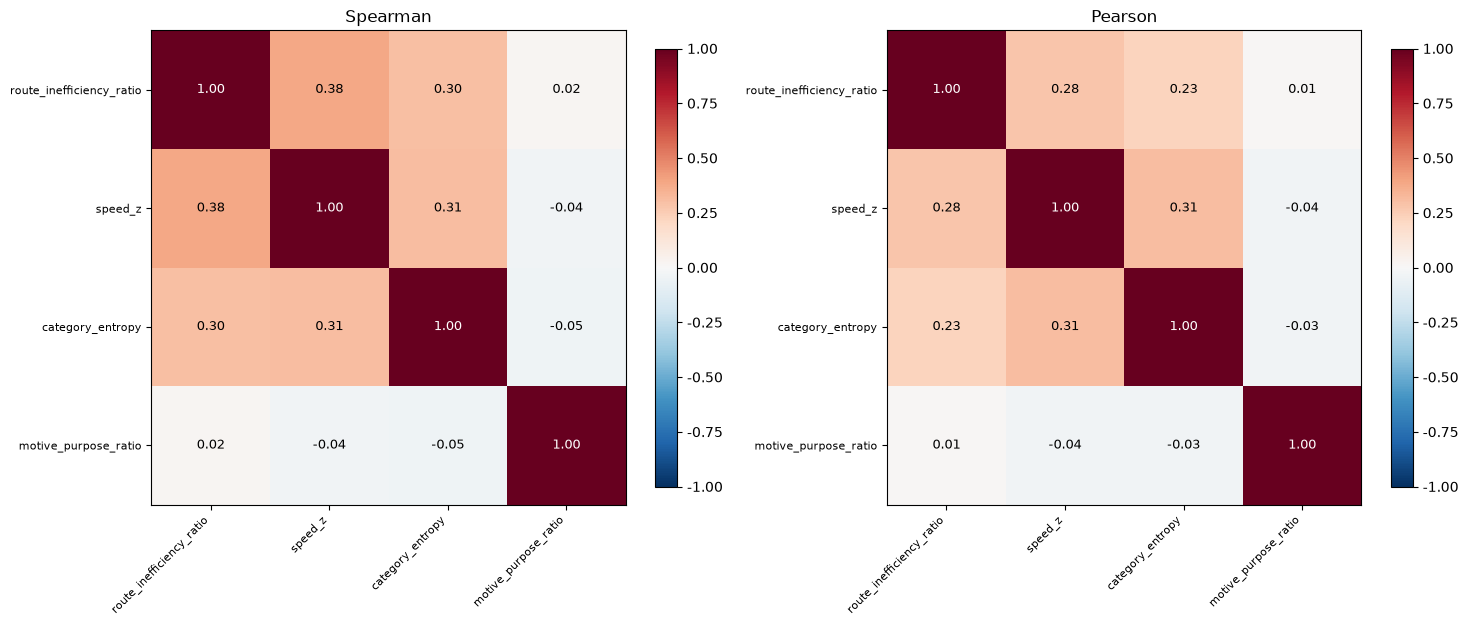

In [8]:
AXES = ['route_inefficiency_ratio', 'speed_z', 'category_entropy', 'motive_purpose_ratio']
sub = feat[AXES].replace([np.inf, -np.inf], np.nan).dropna()
print(f'n = {len(sub)}')
spear = sub.corr(method='spearman')
pears = sub.corr(method='pearson')
spear.to_csv(ROOT / 'outputs/tables/axis_independence_spearman.csv')
fig, axes2 = plt.subplots(1, 2, figsize=(15, 6.5))
for ax, (m, title) in zip(axes2, [(spear, 'Spearman'), (pears, 'Pearson')]):
    im = ax.imshow(m, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_xticks(range(len(AXES)), AXES, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(AXES)), AXES, fontsize=8)
    for i in range(len(AXES)):
        for j in range(len(AXES)):
            ax.text(j, i, f'{m.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9,
                    color='white' if abs(m.iloc[i, j]) > 0.6 else 'black')
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
fig.savefig(ROOT / 'outputs/figures/axis_independence_heatmap.png', dpi=110)
plt.show()

In [9]:
# 유형을 만드는 축은 이 셋. §8 시각화도 AX3 와 binsub 을 그대로 재사용한다.
AX3 = ['route_inefficiency_ratio', 'category_entropy', 'motive_purpose_ratio']

# 이진화 표본은 세 축 기준으로만 만든다. sub 를 쓰면 안 된다 — sub 는 AXES 6개 기준 dropna 라
# 축이 아닌 speed_z·hotplace_ratio·per_person_spend_log 의 결측까지 유형에서 빼버린다(4건).
# ratio ≈ 1.0(최적 동선 달성) 행은 제외한다 — 근거는 §6 설명.
# == 1.0 으로 거르면 안 된다: 부동소수점 탓에 0.9999999999999998 같은 값이 48건 남는다
# (경로가 최적보다 짧을 수 없으므로 1.0 미만 17건은 전부 계산 오차다).
binsub = feat[AX3].replace([np.inf, -np.inf], np.nan).dropna()
n_valid = len(binsub)
binsub = binsub[~np.isclose(binsub['route_inefficiency_ratio'], 1.0)]
print(f'세 축 유효 {n_valid}건 → ratio ≈ 1.0 {n_valid - len(binsub)}건 제외 '
      f'→ 이진화 표본 {len(binsub)}건')

# 세 축 모두 평균 컷으로 통일. J/P만 부등호가 반대인 이유는 '덜 돌아간 쪽'이 J이기 때문.
binar = pd.DataFrame({
    'J(최적동선)': (binsub['route_inefficiency_ratio'] <= binsub['route_inefficiency_ratio'].mean()).astype(int),
    '다양': (binsub['category_entropy'] > binsub['category_entropy'].mean()).astype(int),
    '목적형': (binsub['motive_purpose_ratio'] > binsub['motive_purpose_ratio'].mean()).astype(int),
})  # 속도·핫플 제외 — 근거는 §6 설명. 두 컬럼 다 히트맵에는 남아 있다
print('이진 비율(1의 비중):')
print(binar.mean().round(3).to_string())
print()
print('Phi 상관(이진화 후):')
print(binar.corr().round(3).to_string())
occ = binar.value_counts().sort_index()
print()
n_cells = 2 ** binar.shape[1]  # 축 수에 맞춰 자동 계산
print(f'{n_cells}개 유형 셀 점유: {len(occ)}/{n_cells}, 최소 셀 {occ.min()}건, 최대 셀 {occ.max()}건')
occ

세 축 유효 7670건 → ratio ≈ 1.0 2680건 제외 → 이진화 표본 4990건
이진 비율(1의 비중):
J(최적동선)    0.581
다양         0.523
목적형        0.528

Phi 상관(이진화 후):
         J(최적동선)     다양    목적형
J(최적동선)    1.000 -0.054  0.002
다양        -0.054  1.000 -0.042
목적형        0.002 -0.042  1.000

8개 유형 셀 점유: 8/8, 최소 셀 431건, 최대 셀 807건


J(최적동선)  다양  목적형
0        0   0      431
             1      500
         1   0      559
             1      602
1        0   0      641
             1      807
         1   0      726
             1      724
Name: count, dtype: int64

## 7. 지출액은 무엇을 타는가 — 요인별 분해

지출액은 체감상 설명력이 큰 변수지만, 그 설명력이 **여행자의 성향**에서 오는지 **여행의 상황**에서 오는지 분해해본다. 1인당 지출(log)을 타깃으로 요인 하나씩 회귀해 단독 R²를 계산한다(범주형 더미 처리, 비선형 허용).

이 분해는 두 가지 결정의 근거가 된다: ① 지출을 유형 축이 아니라 유형별 프로필로 배치한 이유, ② 데모가 연령대·권역·동반자유형을 입력받는 것의 의미(지출 예측에 실제로 기여하는 변수들).

In [10]:
# 같은 여행자가 여러 권역 마스터에 나타날 수 있어 중복 제거 후 병합한다
master = pd.concat(
    [pd.read_csv(next((ROOT / f'data/raw/{r}/Training').glob('tn_traveller_master*.csv')))
     for r in REGIONS],
    ignore_index=True).drop_duplicates(subset='TRAVELER_ID')
feat = feat.merge(master[['TRAVELER_ID', 'GENDER']], on='TRAVELER_ID', how='left')
df = feat.dropna(subset=['per_person_spend_won']).copy()
df = df[df.per_person_spend_won > 0]
y = np.log1p(df.per_person_spend_won).to_numpy()

FACTORS = {
    '여행일수': df.trip_days.astype(str),
    '동반자유형': df.TRAVEL_STATUS_ACCOMPANY,
    '동반자수': df.TRAVEL_COMPANIONS_NUM.clip(upper=6).astype(str),
    '연령대': df.AGE_GRP.astype(str),
    '성별': df.GENDER,
    '목적지권역': df.TRAVEL_STATUS_DESTINATION,
    '여행월': df.travel_month.astype(str),
}

def r2_of(cols):
    X = pd.get_dummies(pd.concat(cols, axis=1), drop_first=True).astype(float).to_numpy()
    X = np.column_stack([np.ones(len(X)), X])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return 1 - (y - X @ beta).var() / y.var()

r2s = {name: r2_of([col.rename(name)]) for name, col in FACTORS.items()}
for name, r2 in sorted(r2s.items(), key=lambda t: -t[1]):
    print(f'{name:8s} 단독 R² = {r2:.3f}')
print(f'전체 결합 R² = {r2_of([c.rename(n) for n, c in FACTORS.items()]):.3f}')

여행일수     단독 R² = 0.570
목적지권역    단독 R² = 0.253
동반자유형    단독 R² = 0.048
여행월      단독 R² = 0.046
연령대      단독 R² = 0.030
동반자수     단독 R² = 0.028
성별       단독 R² = 0.003
전체 결합 R² = 0.659


In [11]:
for name, col in [('여행일수', df.trip_days.clip(upper=5)), ('동반자유형', df.TRAVEL_STATUS_ACCOMPANY),
                  ('연령대', df.AGE_GRP), ('성별', df.GENDER)]:
    g = df.groupby(col).per_person_spend_won.agg(['median', 'count']).round(-2)
    print(f'\n[{name}] 1인당 지출 중앙값(원)')
    print(g.to_string())


[여행일수] 1인당 지출 중앙값(원)
             median  count
trip_days                 
1          104200.0      0
2           49600.0   4700
3          151900.0   3400
4          312800.0   1400
5          518700.0    800

[동반자유형] 1인당 지출 중앙값(원)
                           median  count
TRAVEL_STATUS_ACCOMPANY                 
2인 가족 여행                  92500.0   1100
2인 여행(가족 외)              124400.0   3500
3대 동반 여행(친척 포함)          107200.0    200
3인 이상 가족 여행(친척 포함)        38400.0      0
3인 이상 여행(가족 외)           103900.0   1300
나홀로 여행                   132400.0   1900
부모 동반 여행                 107800.0    400
자녀 동반 여행                  63300.0   1700

[연령대] 1인당 지출 중앙값(원)
           median  count
AGE_GRP                 
20       127500.0   3500
30       111700.0   3300
40        86800.0   2000
50        90200.0   1000
60        59500.0    400

[성별] 1인당 지출 중앙값(원)
          median  count
GENDER                 
남       101000.0   4200
여       110400.0   6000


### 해석

- **여행일수가 압도적(R² = 0.570)** — 1박2일 중앙값 5.0만 원 → 2박3일 15.2만 → 3박4일 31.3만 → 4박5일 51.9만. 지출액 변동의 절반 이상이 "얼마나 오래 갔나"만으로 설명된다.
- **목적지권역이 두 번째(R² = 0.253)** — 4권역으로 확장하면서 크게 올라온 항목이다. 동부권만 볼 때는 0.073에 그쳤는데, 제주·수도권·서부권이 들어오자 "어디로 갔나"가 지출을 크게 가른다. 권역별 물가·이동비 차이가 실재한다는 뜻이고, 동시에 **지출을 성향 축으로 쓰기 어렵다는 근거가 하나 늘었다**.
- **동반자유형 0.048, 여행월 0.046, 연령대 0.030, 동반자수 0.028** — 각각은 작지만 실재하는 효과. 자녀 동반(6.3만)이 1인당 지출이 낮고 **나홀로 여행(13.2만)이 가장 높다**(비용 분담이 없어서). 연령대는 20대(12.8만)가 60대(6.0만)보다 두 배 이상 높다.
- **성별은 거의 타지 않는다(R² = 0.003)** — 남 10.1만 vs 여 11.0만.
- **전체 결합 R² = 0.659** — 지출액 변동의 66%가 상황·인구 변수만으로 설명된다. 동부권만일 때(0.601)보다 높아졌다.

### 왜 보정해도 안 되는가 — 구조적 원인

R² 숫자 뒤에는 지표 설계 자체에 박힌 두 가지 구조 문제가 있다.

1. **1인당의 함정**: "총액 ÷ 인원수"는 비용이 인원수에 비례한다고 가정하지만, 여행 비용의 큰 덩어리(숙박·렌터카·기름값)는 나눠 쓰는 고정비다. 4인 가족이 방 하나를 잡으면 1인당 숙박비가 나홀로 여행자의 1/4이 된다. "자녀 동반이 1인당 최저, 나홀로가 최고"는 씀씀이 성향이 아니라 **나눗셈의 결과**다.
2. **여행일수의 함정**: 당일치기엔 숙박비가 없고, 자는 순간 하루 단가가 점프한다. 왕복 교통비 같은 고정비도 여행 길이에 따라 다르게 퍼진다.

즉 지출액은 사람의 씀씀이가 아니라 **여행의 경제 구조**(며칠, 몇 명, 어디로, 고정비 분담)를 재는 지표다.

**결론(팀 확정): 지출액은 축에서 제외**하고 유형별 프로필 지표로 배치한다. 후속 과제: 숙박 1박당 단가, 식사 1회당 단가 같은 **단가 계열 지표**는 고정비 분담 문제를 우회하므로 "씀씀이 성향" 축의 재도전 후보다.

## 8. 확정 3축 시각화

확정된 축: **동선비효율(J/P) × 카테고리 엔트로피(다양/한우물) × 동기(편의형↔목적형)**.

### 8-1. 2축씩 산점도 3장

각 산점도에 이진화 컷 라인(회색 점선)을 함께 그린다 — 세 축 모두 평균(§6.2와 동일 기준). 선으로 나뉜 4개 사분면이 곧 유형 조합이고, **모든 사분면에 점이 고르게 존재하는지**(독립성의 시각적 확인)를 본다. 동선비효율은 오른쪽 꼬리가 길어 표시만 99% 분위수에서 자른다(계산에는 전체 사용). ratio ≈ 1.0(최적 동선 달성) 건은 §6.2와 같은 기준으로 **제외했으므로 세로 띠가 보이지 않는다** — 예전 버전에서 J그룹의 핵으로 설명하던 그 스파이크다.

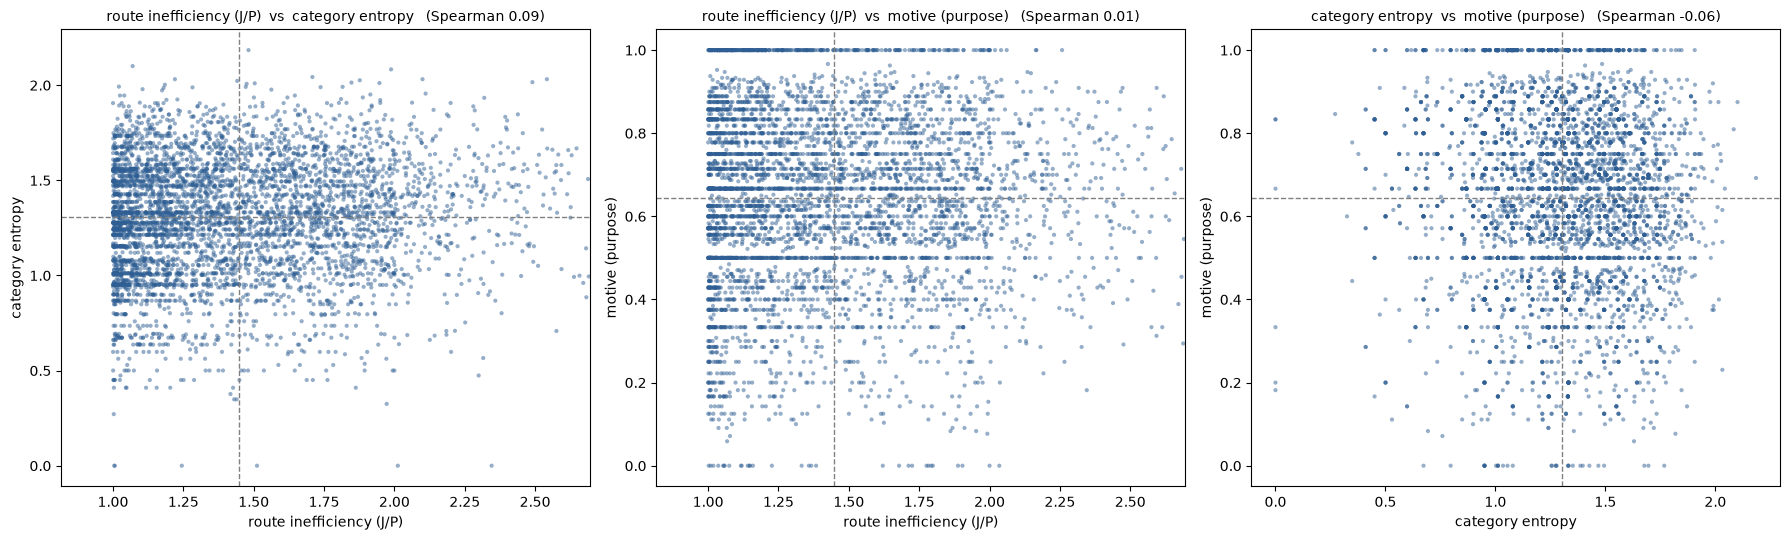

In [12]:
LBL = {'route_inefficiency_ratio': 'route inefficiency (J/P)',
       'category_entropy': 'category entropy',
       'motive_purpose_ratio': 'motive (purpose)'}
# AX3·binsub 은 §6.2에서 만든 것을 그대로 쓴다 — 시각화와 유형 생성이
# 같은 표본·같은 컷을 보게 강제해서 두 절의 숫자가 어긋날 수 없게 한다.
d3 = binsub
CUTS = {c: d3[c].mean() for c in AX3}
pairs = [(AX3[0], AX3[1]), (AX3[0], AX3[2]), (AX3[1], AX3[2])]
fig, axes3 = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (cx, cy) in zip(axes3, pairs):
    x, y2 = d3[cx], d3[cy]
    xmax = np.quantile(x, 0.99) if cx == 'route_inefficiency_ratio' else None
    ax.scatter(x, y2, s=9, alpha=0.5, color='#2e5e93', edgecolors='none')
    ax.axvline(CUTS[cx], color='gray', ls='--', lw=1)
    ax.axhline(CUTS[cy], color='gray', ls='--', lw=1)
    if xmax: ax.set_xlim(right=xmax)
    ax.set_xlabel(LBL[cx]); ax.set_ylabel(LBL[cy])
    rho = d3[[cx, cy]].corr(method='spearman').iloc[0, 1]
    ax.set_title(f'{LBL[cx]}  vs  {LBL[cy]}   (Spearman {rho:.2f})', fontsize=10)
fig.tight_layout()
fig.savefig(ROOT / 'outputs/figures/axis_scatter_pairs.png', dpi=110)
plt.show()

### 8-2. 3차원 시각화는 어떻게 하나

3축이면 점 하나가 (비효율, 엔트로피, 동기) 3좌표를 가지므로 방법이 몇 가지 있다.

1. **3D 산점도** — matplotlib에서 `add_subplot(projection='3d')`로 만든다. 한 화면에 전체 구조가 보여서 발표 도입부 임팩트용으로 좋지만, 점이 서로 가리고(occlusion) 보는 각도에 따라 왜곡되므로 **정확한 판독용은 아니다**. 노트북에서는 `%matplotlib widget`, 또는 plotly를 쓰면 마우스로 회전하며 볼 수 있다.
2. **2D 산점도 + 색으로 3번째 축** — 두 축은 위치로, 세 번째 축은 색(단일 색조, 밝음→어두움)으로 인코딩. 가림 문제가 없고 인쇄물에서도 안전해서 **분석용으로는 이쪽이 표준**이다.
3. **위의 8-1처럼 2축씩 쪼개기(pair plot)** — 가장 정직한 방법. 3D의 모든 정보는 결국 세 단면에 다 들어 있다.

아래에 1번(3D, J/P를 색으로 강조)과 2번(색 인코딩)을 나란히 그린다.

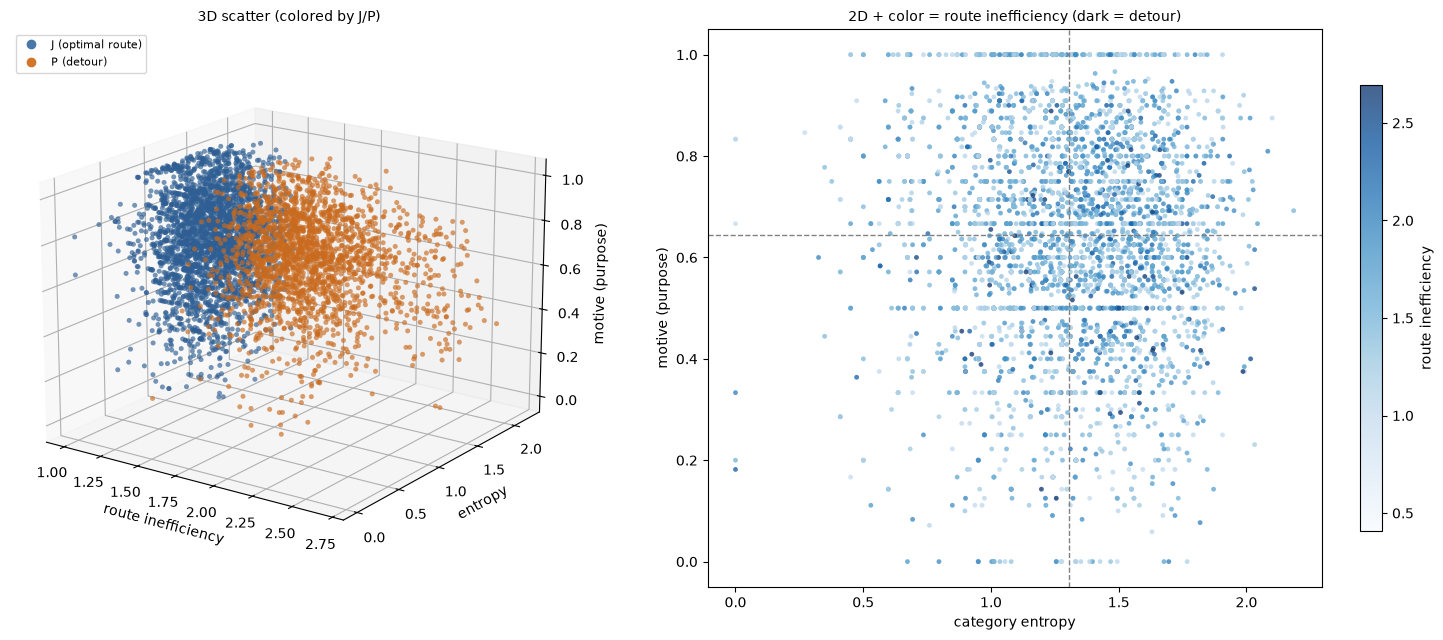

In [13]:
from matplotlib.lines import Line2D
fig = plt.figure(figsize=(16, 6.5))
# (1) 3D 산점도 — J/P를 색으로
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
isJ = d3['route_inefficiency_ratio'] <= CUTS['route_inefficiency_ratio']
rt = d3['route_inefficiency_ratio'].clip(upper=np.quantile(d3['route_inefficiency_ratio'], 0.99))
for mask, c, lab in [(~isJ, '#c96a1e', 'P (detour)'), (isJ, '#2e5e93', 'J (optimal route)')]:
    ax1.scatter(rt[mask], d3.loc[mask, 'category_entropy'], d3.loc[mask, 'motive_purpose_ratio'],
                s=13, alpha=0.65, color=c, edgecolors='none', depthshade=False)
ax1.view_init(elev=18, azim=-55)
ax1.set_xlabel('route inefficiency'); ax1.set_ylabel('entropy'); ax1.set_zlabel('motive (purpose)')
ax1.set_title('3D scatter (colored by J/P)', fontsize=10)
ax1.legend(handles=[Line2D([], [], marker='o', ls='', color='#4878a8', label='J (optimal route)'),
                    Line2D([], [], marker='o', ls='', color='#d1752b', label='P (detour)')],
           loc='upper left', fontsize=8)
# (2) 2D + 색으로 3번째 축
ax2 = fig.add_subplot(1, 2, 2)
import matplotlib.colors as mcolors
# 밝은 끝이 흰 배경에 묻히지 않게 vmin을 낮춰 램프의 연한 구간을 건너뜀
norm = mcolors.Normalize(vmin=rt.min() - 0.35 * (rt.max() - rt.min()), vmax=rt.max())
sc = ax2.scatter(d3['category_entropy'], d3['motive_purpose_ratio'], c=rt, norm=norm,
                 s=12, alpha=0.75, cmap='Blues', edgecolors='none')
ax2.axvline(CUTS['category_entropy'], color='gray', ls='--', lw=1)
ax2.axhline(CUTS['motive_purpose_ratio'], color='gray', ls='--', lw=1)
ax2.set_xlabel('category entropy'); ax2.set_ylabel('motive (purpose)')
ax2.set_title('2D + color = route inefficiency (dark = detour)', fontsize=10)
fig.colorbar(sc, ax=ax2, shrink=0.8, label='route inefficiency')
fig.tight_layout()
fig.savefig(ROOT / 'outputs/figures/axis_3d_visualization.png', dpi=110)
plt.show()

### 8-3. 8유형 단면 — 축 하나를 고정하고 나머지 평면 보기

3D는 점이 서로 가려서 정확한 판독이 어렵다. 축 하나를 골라 그 축의 컷을 기준으로 **데이터를 둘로 자른 뒤**, 남은 두 축의 평면을 보면 가림 없이 8유형이 전부 드러난다.

읽는 법:
- 한 **열**이 "어떤 축으로 잘랐는가"이고, 위/아래가 그 축의 두 쪽이다.
- 각 패널 안의 점선은 나머지 두 축의 컷(**전체 평균으로 고정** — 단면마다 다시 계산하면 사분면이 실제 유형 셀과 어긋난다).
- 사분면의 숫자가 그 유형에 속한 여행 건수다. 패널 4칸 × 위아래 2개 = 8유형.
- **세 열에 같은 8개 숫자가 자리만 바꿔 나타난다.** 다르게 나오면 컷이 잘못 걸린 것이다.

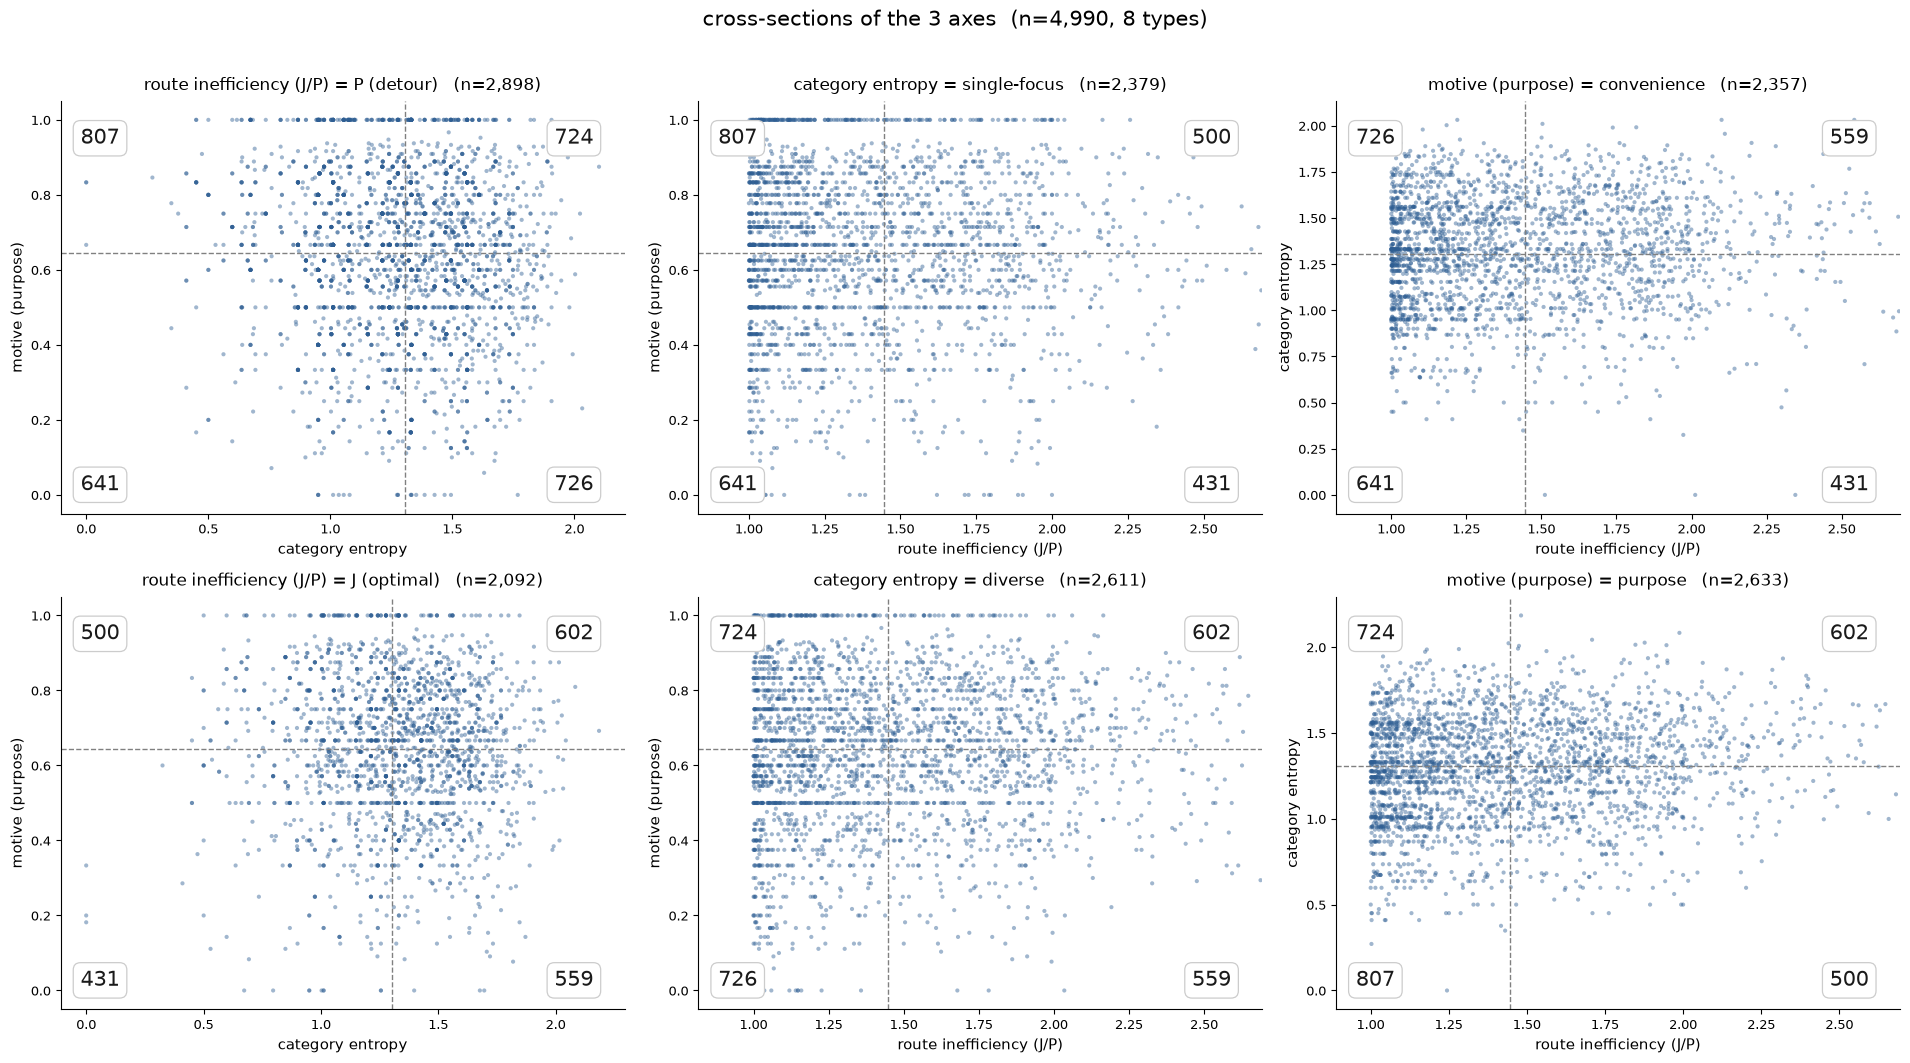

In [14]:
# 축 하나를 고정하고 나머지 두 축의 단면을 본다. 컷은 §6.2와 같은 전체 평균으로 고정한다.
# 열 = 자르는 축, 행 = 그 축의 낮은 쪽 / 높은 쪽.
SIDE = {'route_inefficiency_ratio': ('P (detour)', 'J (optimal)'),   # 낮은 쪽이 J
        'category_entropy':         ('single-focus', 'diverse'),
        'motive_purpose_ratio':     ('convenience', 'purpose')}

# 발표 슬라이드에 그대로 올릴 수 있게 16:9 (110dpi → 2112x1188)
fig, axes4 = plt.subplots(2, 3, figsize=(19.2, 10.8))
for col, slicer in enumerate(AX3):
    cx, cy = [c for c in AX3 if c != slicer]
    hi = d3[slicer] > CUTS[slicer]
    xmax = np.quantile(d3[cx], 0.99) if cx == 'route_inefficiency_ratio' else None
    for row, (mask, name) in enumerate([(~hi, SIDE[slicer][0]), (hi, SIDE[slicer][1])]):
        ax = axes4[row, col]
        s = d3[mask]
        ax.scatter(s[cx], s[cy], s=9, alpha=0.45, color='#2e5e93', edgecolors='none')
        ax.axvline(CUTS[cx], color='gray', ls='--', lw=1)
        ax.axhline(CUTS[cy], color='gray', ls='--', lw=1)
        if xmax: ax.set_xlim(right=xmax)
        for qx in (0, 1):          # 사분면별 건수 = 유형 셀 크기
            for qy in (0, 1):
                mx = s[cx] > CUTS[cx] if qx else s[cx] <= CUTS[cx]
                my = s[cy] > CUTS[cy] if qy else s[cy] <= CUTS[cy]
                ax.annotate(f'{int((mx & my).sum())}',
                            xy=(0.07 + 0.84 * qx, 0.07 + 0.84 * qy), xycoords='axes fraction',
                            ha='center', va='center', fontsize=15, color='#1a1a1a',
                            bbox=dict(boxstyle='round,pad=0.35', fc='white', ec='#cccccc', lw=0.9))
        ax.set_xlabel(LBL[cx], fontsize=11); ax.set_ylabel(LBL[cy], fontsize=11)
        ax.set_title(f'{LBL[slicer]} = {name}   (n={len(s):,})', fontsize=12.5, pad=8)
        ax.tick_params(labelsize=9.5)
        for sp in ('top', 'right'): ax.spines[sp].set_visible(False)

fig.suptitle(f'cross-sections of the 3 axes  (n={len(d3):,}, 8 types)', fontsize=15)
fig.tight_layout(rect=(0, 0, 1, 0.965))
fig.savefig(ROOT / 'outputs/figures/axis_cross_sections.png', dpi=110)
plt.show()

## 판정 요약

> 4권역 Training 전체 10,240건 기준. 동부권만 쓰던 이전 판정과 수치가 다르며, `route_inefficiency` 정의도 바뀌었다(§0).

### ✅ 축 적합: `motive_purpose_ratio`, `hotplace_ratio`, `category_entropy`, `speed_z`
넷 다 dip 유의(p≈0) **그리고** GMM 2성분 우세로 두 지표가 교차 확인됐다. GMM이 찾은 두 그룹도 해석이 자연스럽다.

| 컬럼 | dip | ΔBIC | 두 그룹 (중심 / 비중) |
|---|---|---|---|
| `motive_purpose_ratio` | **0.0736** | 415.8 | 편의 혼합 0.43 (39%) / 목적 중심 0.77 (61%) |
| `hotplace_ratio` | 0.0558 | 818.6 | 탐험 0.42 (47%) / 추종 0.81 (53%) |
| `category_entropy` | 0.0553 | 479.6 | 한 우물 0.87 (45%) / 다양 1.32 (55%) |
| `speed_z` | 0.0178 | 961.2 | 빡빡 0.81 (33%) / 느긋 −0.40 (67%) |

동기의 dip 통계량 0.0736이 9개 후보 중 최대다.

### ⚠️ 조건부 적합: `route_inefficiency_ratio` (J/P)
dip이 **완전히 비유의(p = 1.0000)** 다. 그러나 이는 봉우리가 없어서가 아니라 분포에 **점질량**이 있어서다 — ratio 유효 7,670건 중 **2,680건(34.9%)이 정확히 1.0**이고 나머지가 우회 꼬리를 그린다. GMM은 이 구조를 두 성분(중심 1.000 비중 36% / 중심 1.451 비중 64%)으로 명확히 잡아내며 ΔBIC가 29,840으로 압도적이다. BC도 0.561로 유일하게 0.555 기준을 넘는다.

즉 "최적 동선파 vs 우회파"라는 자연 경계는 존재한다. 다만 **현재 코드는 그 경계에서 자르지 않는다** — 컷 기준을 세 축 모두 평균으로 통일했고, 오히려 1.0 집단을 이진화 표본에서 제외한다(§6 맞바꿈).

### ❌ 약함: 지출액 (raw/log 모두)
log 변환 버전은 **ΔBIC가 음수**(1인당 −26.5, 총액 −51.0)로 1성분이 이긴다. 단봉이 확정적이다. raw 버전의 ΔBIC가 1만을 넘는 것은 이봉성이 아니라 **오른쪽 긴 꼬리를 두 정규분포로 근사**한 결과이며, dip은 p=1.0으로 단봉을 지지한다. 축이 아니라 유형별 프로필 지표로 쓴다(§7).

### 통계적 주의사항
속도·엔트로피·핫플·동기는 모두 작은 정수에서 파생된 비율이라 값이 준이산적(0, 0.5, 0.67, …)이고, dip test는 이산적 계단을 봉우리로 오인해 이봉성을 과대평가할 수 있다. **동기는 이 주의가 특히 크게 걸린다** — 방문지 3곳 중 2곳이면 정확히 0.667이라 중앙값에만 930건이 몰려 있다. 다만 네 후보 모두 연속 모형인 GMM ΔBIC도 2성분을 지지하므로 결론은 유지된다.

### 독립성 체크 결과 (연속값 Spearman, n = 7,670)

| 쌍 | ρ | 판정 |
|---|---|---|
| 동선비효율 ↔ 속도 | 0.384 | 주의 |
| 속도 ↔ 엔트로피 | 0.306 | 주의 (경계) |
| 동선비효율 ↔ 엔트로피 | 0.298 | 양호 (경계) |
| 엔트로피 ↔ 동기 | −0.046 | 양호 |
| 속도 ↔ 동기 | −0.038 | 양호 |
| 동선비효율 ↔ 동기 | 0.016 | 양호 |

- **동기는 거의 완벽하게 직교** — 다른 세 축과 |ρ| ≤ 0.046. 가장 독립적인 축이다.
- **속도가 여전히 가장 얽히는 축**이지만 정도가 약해졌다 — 동부권만 쓸 때 엔트로피와 0.44였던 것이 **0.306**으로 내려왔다. "0.4 이상으로 얽히는 허브"라는 기존 판단은 이 데이터에서 더 이상 성립하지 않는다. **속도의 축 재도전을 검토할 만하다.**
- **핫플은 후보 풀에서 제외** — 통계적으로는 축 자격을 갖췄지만(dip 0.0558, ΔBIC 818.6) 지표 정의가 표본 노이즈와 이름 표기 흔들림에 좌우되고, 동기와 개념이 겹친다(§2·§6).

### 이진화 결과 (표본 4,990건)

이진 비율은 J 0.581 / 다양 0.523 / 목적형 0.528로 세 축 모두 반반에 가깝다. 이진화 후 phi는 **최대 0.054**(J↔다양)로 세 쌍 모두 0.06 미만이다. 8개 유형 셀이 전부 점유되고 **최소 431건, 최대 807건**(최대/최소 1.9배)으로 분포가 고르다. §6.2와 §8은 같은 `binsub`을 공유하므로 두 절의 셀 건수는 항상 일치한다.

**최종 확정(팀 결정)**: **동선비효율(J/P) × 엔트로피(다양성) × 동기(편의형↔목적형) 3축 = 8유형**. 제외 사유는 셋으로 갈린다 — **속도**는 남은 축들과 가장 얽히고(통계적 중복, 단 4권역에서 근거 약화), **핫플 비율**은 지표 정의 결함과 동기와의 의미 중복, **지출액**은 사람의 성향이 아니라 여행의 상황 구조를 재는 지표여서(§7) 제외한다. 속도·핫플·지출액은 유형별 프로필 지표로 활용한다.

**표본에 대한 해석**: 최종 4,990건은 전체 10,240건의 48.7%지만, 이는 손실이라기보다 **필터**로 읽는 편이 정확하다. 제외되는 5,250건은 관광 방문지 중앙값 3~5곳·1박2일 일정으로, 동선 효율을 논할 대상이 아니다(최종 표본은 10곳·2박3일). 중간 좌표가 2곳이면 ratio가 구조적으로 항상 1.0이라는 점도 같은 이야기다(§0).

**남은 과제**: 그럼에도 J/P 축은 다른 두 축보다 표본을 절반으로 줄인다. '짧은 여행은 유형 분류에서 빼는 것이 맞는가'는 통계가 아니라 서비스 설계의 질문이므로, 1박2일 여행자에게도 유형을 부여해야 한다면 동선을 뺀 2축(4유형, n≈10,234) 구성을 별도로 준비해야 한다.
